# The SIDM background estimate from first principles — Part 2: closure tests and the 4mu verdict

Part 1 defined the samples, the event selection, the ABCD variables, the blinding
scheme, and presented the deployed 2mu2e estimate. This notebook is the evidence
file behind the two central claims:

1. **In the 4mu channel, no isolation-based ABCD plane closes** — not the naive
   plane, not conditioned variants, not cross-object variants, not after removing
   the instrumental background with a vertex requirement. The failure is a
   genuine isolation–isolation–mJJ correlation of the physical background, not a
   statistical fluctuation and not an artifact of a single convention.
2. The isolated 4mu corner is dominated by a **jet-unmatched, DSA-only,
   back-to-back instrumental population** not seen in the simulation samples
   inspected during the campaign, and a **dimuon-vertex-quality requirement**
   removes ~98% of it while keeping 58–85% of signal at the χ² < 5 working
   point (signal efficiency from simulation; the genuine-vs-fake separation is
   validated in data with a prompt Z → μμ control). Any future 4mu method
   builds on this discriminant.

All numbers are recomputed live from the merged full-2018 campaigns
(`AbcdVtx_Run2018_v1`, local cache `abcd_vtx_local/`; and the dedicated
cross-plane pass `AbcdVtxCross_Run2018_v2`, cache `abcd_vtxcross_local/`).
Signal-region bins were never filled for data (Part 1, Section 6).

In [1]:
import glob, os, math, json
import numpy as np
import coffea.util as cu
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.CMS)

CACHE_VTX   = "/uscms_data/d3/murtazas/abcd_vtx_local"        # AbcdVtx_Run2018_v1
CACHE_CROSS = "/uscms_data/d3/murtazas/abcd_vtxcross_local"   # AbcdVtxCross_Run2018_v2 (slim)
DATA_CH = {"2mu2e": "2mu2e_abcd_scan_data_full", "4mu": "4mu_abcd_scan_data_full"}
SIG_CH  = {"2mu2e": "2mu2e_abcd_scan",           "4mu": "4mu_abcd_scan"}

def load_sum(cache, pattern, keep):
    '''Sum the named histograms over all merged .coffea files matching pattern.'''
    H, n = {}, 0
    for f in sorted(glob.glob(cache + "/" + pattern)):
        o = cu.load(f)
        o = o["out"] if isinstance(o, dict) and "out" in o else o
        for ds in o.values():
            hh = ds["hists"] if "hists" in ds else ds
            for k in keep:
                H[k] = hh[k].copy() if k not in H else H[k] + hh[k]
        n += 1
    return H, n

def edges(h): return {a.name: np.asarray(a.edges) for a in h.axes}

def eix(ax_edges, v):
    i = int(np.argmin(np.abs(ax_edges - v)))
    assert np.isclose(ax_edges[i], v), f"no exact edge at {v}: nearest {ax_edges[i]}"
    return i

def val(x):
    return float(x.value) if hasattr(x, "value") else float(np.asarray(x.view()["value"]).sum())

def cp_interval(k, n, cl=0.68):
    from scipy import stats as st
    if n == 0: return (0.0, 1.0)
    a = (1 - cl) / 2
    lo = st.beta.ppf(a, k, n - k + 1) if k > 0 else 0.0
    hi = st.beta.ppf(1 - a, k + 1, n - k) if k < n else 1.0
    return (lo, hi)

def closure(A, B, Cc, D):
    '''R = A*D/(B*C) with Poisson-propagated uncertainty.'''
    if min(B, Cc) <= 0: return float("nan"), float("nan")
    R = A * D / (B * Cc)
    dR = R * math.sqrt(sum(1 / max(x, 1.0) for x in (A, B, Cc, D)))
    return R, dR

HX, nx = load_sum(CACHE_CROSS, "DoubleMuon_*.coffea", keep=["abcd_vtxcross2_4mu"])
hx = HX["abcd_vtxcross2_4mu"][{"channel": DATA_CH["4mu"]}]
ex = edges(hx)
print("cross-plane cache: %d merged data files; axes:" % nx,
      [a.name for a in hx.axes])

cross-plane cache: 68 merged data files; axes: ['vchi2lead', 'muiso0', 'muiso1', 'mudisp0', 'mudisp1', 'mjj', 'parity']


## 1. The 4mu closure engine

Every 4mu closure test below is computed from **one histogram**,
`abcd_vtxcross2_4mu`, which carries the full six-dimensional space
(vertex category of the leading LJ) × (iso of both LJs) × (pixel-displacement of
both LJs) × mJJ, filled in the blinded data channel. This guarantees all the
variants are computed on *exactly the same events* with *exactly the same
conventions* — the differences between them are real, not bookkeeping.

For planes with mJJ as an axis, the closure window is the mJJ sideband:
**A-window mJJ ∈ [100, 150) GeV** (as close to the signal region as blinding
allows) against the **control window mJJ ∈ [50, 100)**; planes built from two
per-LJ variables are closed as quadrant ratios inside mJJ ∈ [50, 150)
(Section 3). Working points as in Part 1: iso < 0.25, pixel-displacement
< 2.5. Conventions:

* **sent-in** — the sentinel bin (iso ∈ [−0.02, 0) = "no jet match";
  disp = −1 = "DSA-only") counts on the *pass* side of its axis (this matches how
  the blind box and the deployed 2mu2e estimate treat it);
* **sent-out** — sentinel events are excluded from the axis entirely.

The helper below slices out any (x-axis, mJJ-window) closure with any set of
conditions on the remaining axes.

In [2]:
def closure_4mu(xaxis, xcut, cond=None, sentinel="in"):
    '''Window closure of (xaxis vs mJJ) in abcd_vtxcross2_4mu.

    xaxis: "muiso0"/"muiso1"/"mudisp0"/"mudisp1"; xcut: pass = value < xcut.
    cond:  dict of extra requirements, e.g. {"muiso0": ("lt", 0.25)} or
           {"vchi2lead": ("window", 0.0, 5.0)}.
    sentinel: "in" (sentinel bin on the pass side) or "out" (excluded).
    Returns (A, B, C, D, R, dR).
    '''
    sel = {"parity": sum}
    for ax in ("vchi2lead", "muiso0", "muiso1", "mudisp0", "mudisp1"):
        if ax == xaxis: continue
        c = (cond or {}).get(ax)
        if c is None:
            sel[ax] = sum
        elif c[0] == "lt":
            sel[ax] = slice(0, eix(ex[ax], c[1]), sum)          # sent-in pass
        elif c[0] == "window":
            sel[ax] = slice(eix(ex[ax], c[1]), eix(ex[ax], c[2]), sum)
    # upper edge of the sentinel bin: iso axes [-0.02,0), disp axes [-1.5,-0.5)
    sent_edge = 0.0 if xaxis.startswith("muiso") else -0.5
    lo = eix(ex[xaxis], sent_edge) if sentinel == "out" else 0
    icut = eix(ex[xaxis], xcut)
    j50, j100, j150 = (eix(ex["mjj"], v) for v in (50., 100., 150.))
    out = {}
    for name, (xs, ys) in {
            "A": (slice(lo, icut, sum),                    slice(j100, j150, sum)),
            "B": (slice(icut, len(ex[xaxis]) - 1, sum),    slice(j100, j150, sum)),
            "C": (slice(lo, icut, sum),                    slice(j50, j100, sum)),
            "D": (slice(icut, len(ex[xaxis]) - 1, sum),    slice(j50, j100, sum))}.items():
        s = dict(sel); s[xaxis] = xs; s["mjj"] = ys
        out[name] = val(hx[s])
    R, dR = closure(out["A"], out["B"], out["C"], out["D"])
    return out["A"], out["B"], out["C"], out["D"], R, dR

def report(label, res):
    A, B, Cc, D, R, dR = res
    print("%-58s A=%6.0f B=%6.0f C=%6.0f D=%6.0f  R = %.3f +- %.3f"
          % (label, A, B, Cc, D, R, dR))

## 2. Raw isolation ABCD in 4mu: non-closure by factors of 3–35

Before any cleaning, apply the ABCD construction exactly as one would naively
build it — subleading-LJ isolation × mJJ, then the same conditioned on the
leading LJ being isolated (which the signal region requires), then the
cross-object and same-LJ pairings analogous to the deployed 2mu2e plane.

Nothing closes. The ratios are not off by tens of percent — they are off by
factors of **3 to 35**. Section 4 identifies the dominant culprit: an
instrumental population that floods the "isolated" side of every isolation
axis. But keep Section 6 in mind — removing that population is *necessary and
still not sufficient*.

In [3]:
report("raw: muiso1 x mJJ, unconditioned (sent-in)",
       closure_4mu("muiso1", 0.25))
report("raw: muiso1 x mJJ | muiso0<0.25 (sent-in)",
       closure_4mu("muiso1", 0.25, cond={"muiso0": ("lt", 0.25)}))
report("raw: muiso1 x mJJ | muiso0<0.25 (sent-out)",
       closure_4mu("muiso1", 0.25, cond={"muiso0": ("lt", 0.25)}, sentinel="out"))

raw: muiso1 x mJJ, unconditioned (sent-in)                 A=  3900 B=  6653 C=  1145 D=  5591  R = 2.862 +- 0.109


raw: muiso1 x mJJ | muiso0<0.25 (sent-in)                  A=  3430 B=  1114 C=   623 D=   818  R = 4.043 +- 0.256


raw: muiso1 x mJJ | muiso0<0.25 (sent-out)                 A=   632 B=  1114 C=   209 D=   818  R = 2.220 +- 0.205


## 3. Raw cross-object planes fail too

The deployed 2mu2e plane pairs a variable of one LJ with a variable of the
*other* LJ. The exact 4mu analog — isolation of one muon-LJ × pixel-displacement
of the other — is computed below in both orientations, plus the conditioned and
same-LJ variants. (These planes do not use mJJ as an axis; the counts are taken
in the mJJ ∈ [50, 150) sideband, and the closure is the plane's own quadrant
ratio there.)

In [4]:
def closure_plane(xaxis, xcut, yaxis, ycut, cond=None, sentinel="in"):
    '''Quadrant closure of (xaxis x yaxis) in the mJJ [50,150) sideband.'''
    sel = {"parity": sum, "mjj": slice(eix(ex["mjj"], 50.), eix(ex["mjj"], 150.), sum)}
    for ax in ("vchi2lead", "muiso0", "muiso1", "mudisp0", "mudisp1"):
        if ax in (xaxis, yaxis): continue
        c = (cond or {}).get(ax)
        if c is None: sel[ax] = sum
        elif c[0] == "lt": sel[ax] = slice(0, eix(ex[ax], c[1]), sum)
        elif c[0] == "window": sel[ax] = slice(eix(ex[ax], c[1]), eix(ex[ax], c[2]), sum)
    def side(ax, cut, p):
        sent_edge = 0.0 if ax.startswith("muiso") else -0.5
        lo = eix(ex[ax], sent_edge) if sentinel == "out" else 0
        i = eix(ex[ax], cut)
        return slice(lo, i, sum) if p else slice(i, len(ex[ax]) - 1, sum)
    out = {}
    for name, (xp, yp) in {"A": (1, 1), "B": (0, 1), "C": (1, 0), "D": (0, 0)}.items():
        s = dict(sel); s[xaxis] = side(xaxis, xcut, xp); s[yaxis] = side(yaxis, ycut, yp)
        out[name] = val(hx[s])
    R, dR = closure(out["A"], out["B"], out["C"], out["D"])
    return out["A"], out["B"], out["C"], out["D"], R, dR

report("raw cross: muiso1 x mudisp0, unconditioned (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp0", 2.5))
report("raw cross: muiso0 x mudisp1, unconditioned (sent-in)",
       closure_plane("muiso0", 0.25, "mudisp1", 2.5))
report("raw cross: muiso1 x mudisp0 | muiso0<0.25 (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp0", 2.5, cond={"muiso0": ("lt", 0.25)}))
report("raw same-LJ: muiso1 x mudisp1, unconditioned (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp1", 2.5))

raw cross: muiso1 x mudisp0, unconditioned (sent-in)       A=  3475 B=  1015 C=  1570 D= 11229  R = 24.487 +- 1.095


raw cross: muiso0 x mudisp1, unconditioned (sent-in)       A=  3555 B=  1015 C=  2430 D= 10289  R = 14.830 +- 0.625


raw cross: muiso1 x mudisp0 | muiso0<0.25 (sent-in)        A=  3377 B=   239 C=   676 D=  1693  R = 35.387 +- 2.864


raw same-LJ: muiso1 x mudisp1, unconditioned (sent-in)     A=  3515 B=  1055 C=  1530 D= 11189  R = 24.365 +- 1.083


## 4. What lives in the isolated 4mu corner: the instrumental artifact

Composition of the isolated corner (mJJ sideband), from the campaign
histograms:

* the corner is dominated by the **sentinel** isolation bin — LJs with *no
  matched PF jet at all*, i.e. "isolated" only in the sense that nothing was
  reconstructed to measure: 54% of the lead-isolated corner, and 78% of the
  fully isolated corner (both LJs iso-pass), carry a sentinel leading LJ;
* those sentinel LJs are almost all **DSA-only** (pixel-displacement sentinel
  −1): no PF muon, no tracker information;
* event scans show the muon pairs are **back-to-back** with divergent
  point-of-closest-approach geometry — inconsistent with a single cosmic-ray
  track crossing the detector (a dedicated cosmic study, including a
  collinearity veto that remains in the selection, is documented in the campaign
  log), and **absent from simulation**: a detector/reconstruction artifact
  population, not a physical process;
* a **dimuon-vertex-fit requirement kills it**: demanding that the leading LJ
  contain a muon pair with a refitted common vertex of normalized χ² < 5
  (the `DSAMuonVertex`/`PatMuonVertex`/`PatDSAMuonVertex` collections of
  LLPNanoAOD, the long-lived-particle NanoAOD extension this analysis reads)
  retains only ~2.3% of this population — measured below with Clopper–Pearson
  intervals, stable across the two mJJ windows tested.

In [5]:
HV, nv = load_sum(CACHE_VTX, "DoubleMuon_*.coffea", keep=["abcd_vtx_4mu"])
h4 = HV["abcd_vtx_4mu"][{"channel": DATA_CH["4mu"]}]
e4 = edges(h4)
print("vertex-campaign cache: %d merged data files" % nv)

# Corner composition: leading-LJ iso pass (incl sentinel), mJJ in [50,150)
base = {"vchi2lead": sum, "vchi2sub": sum, "mudisp0": sum, "parity": sum,
        "mjj": slice(eix(e4["mjj"], 50.), eix(e4["mjj"], 150.), sum)}
corner = val(h4[dict(base, muiso0=slice(0, eix(e4["muiso0"], 0.25), sum))])
sentin = val(h4[dict(base, muiso0=slice(0, eix(e4["muiso0"], 0.0), sum))])
print("\nIsolated corner (muiso0<0.25, mJJ 50-150): N = %.0f" % corner)
print("  of which sentinel ('no jet match'):       %.0f  (%.1f%%)"
      % (sentin, 100 * sentin / corner))

dsa = val(h4[dict(base, muiso0=slice(0, eix(e4["muiso0"], 0.0), sum),
                  mudisp0=slice(0, eix(e4["mudisp0"], -0.5), sum))])
print("  sentinel events that are also DSA-only:   %.0f  (%.1f%% of sentinel)"
      % (dsa, 100 * dsa / max(sentin, 1)))

# The fully isolated corner (both LJs iso-pass), from the cross-plane histogram
bboth = {"vchi2lead": sum, "mudisp0": sum, "mudisp1": sum, "parity": sum,
         "mjj": slice(eix(ex["mjj"], 50.), eix(ex["mjj"], 150.), sum)}
nboth = val(hx[dict(bboth, muiso0=slice(0, eix(ex["muiso0"], 0.25), sum),
                    muiso1=slice(0, eix(ex["muiso1"], 0.25), sum))])
nsent = val(hx[dict(bboth, muiso0=slice(0, eix(ex["muiso0"], 0.0), sum),
                    muiso1=slice(0, eix(ex["muiso1"], 0.25), sum))])
print("\nFully isolated corner (both LJs iso<0.25, mJJ 50-150): N = %.0f" % nboth)
print("  of which the leading LJ is sentinel:                 %.0f  (%.1f%%)"
      % (nsent, 100 * nsent / nboth))

# Vertex-requirement survival of the artifact (sentinel) population
for lo, hi in [(50., 150.), (100., 150.)]:
    s = {"vchi2sub": sum, "mudisp0": sum, "parity": sum,
         "muiso0": slice(0, eix(e4["muiso0"], 0.0), sum),
         "mjj": slice(eix(e4["mjj"], lo), eix(e4["mjj"], hi), sum)}
    v = h4[s].view()["value"]
    tot, novtx = v.sum(), v[0]
    good = v[1:eix(e4["vchi2lead"], 5.)].sum()
    clo, chi = cp_interval(int(good), int(tot))
    print("\nArtifact survival of 'vertex with chi2<5' (mJJ %.0f-%.0f):" % (lo, hi))
    print("  N=%.0f  no-vertex=%.0f (%.1f%%)  chi2<5=%.0f  ->  survival %.2f%%  CI68 [%.2f, %.2f]%%"
          % (tot, novtx, 100 * novtx / tot, good, 100 * good / tot, 100 * clo, 100 * chi))

vertex-campaign cache: 68 merged data files

Isolated corner (muiso0<0.25, mJJ 50-150): N = 5976
  of which sentinel ('no jet match'):       3239  (54.2%)
  sentinel events that are also DSA-only:   3226  (99.6% of sentinel)



Fully isolated corner (both LJs iso<0.25, mJJ 50-150): N = 4053
  of which the leading LJ is sentinel:                 3183  (78.5%)



Artifact survival of 'vertex with chi2<5' (mJJ 50-150):
  N=3239  no-vertex=3107 (95.9%)  chi2<5=73  ->  survival 2.25%  CI68 [1.99, 2.54]%

Artifact survival of 'vertex with chi2<5' (mJJ 100-150):
  N=2807  no-vertex=2691 (95.9%)  chi2<5=61  ->  survival 2.17%  CI68 [1.90, 2.48]%


## 5. Validating the vertex discriminant

A cut that kills 98% of the background is only useful if (a) it keeps the
signal, and (b) its behavior on genuine muon pairs is understood in *data*,
not just simulation. The two validations below cover these separately — and
their limits are stated explicitly.

**Signal efficiency (simulation only).** The "leading-LJ has a within-LJ
vertex with χ²/ndf below threshold" requirement, applied to every signal point
in the campaign: 58–85% at χ² < 5. The figure shows this working point versus
dark-photon lifetime; there is no efficiency cliff at long lifetime, and the
spread is driven by the dark-photon mass (more collimated pairs at low mass
fit slightly less often). These efficiencies come from simulation — there is
no displaced-dimuon data control.

**Genuine muon pairs in data (prompt Z → μμ control).** From a standalone
campaign study (`z_control.py`, not committed with this series): Z-peak
dimuons where both legs are also reconstructed as DSA muons — kinematically
genuine pairs, in data — get a fitted vertex 66% of the time (simulation:
69%; data/simulation scale factor 0.92–0.96), against the 2.3% measured above
for the artifact population: a ~29× genuine-vs-fake separation in data itself.
These control pairs are *prompt*; transferring the data/simulation scale
factor to displaced pairs is an extrapolation, supported by the absence of a
lifetime trend in simulation but carrying its own unquantified uncertainty.

**The residual is genuine.** The few artifact-corner events that do pass the
vertex cut cluster at low χ² — they are real muon pairs hiding in the artifact
category, i.e. background to *estimate*, not evidence against the cut.

**How to read the figure**: each marker is one signal grid point (color =
dark-photon mass, x = proper lifetime, log scale); y = fraction of
signal-region events whose leading LJ has a χ² < 5 vertex, with 68%
Clopper–Pearson intervals. The dashed line is the artifact survival measured
above — the separation between every signal point and that line is the working
margin of any vertex-based method.

4Mu_1000GeV_1p2GeV_0p0096mm        N=158263  eff(chi2<5) =   79%


4Mu_1000GeV_1p2GeV_0p96mm          N= 82623  eff(chi2<5) =   69%


4Mu_1000GeV_1p2GeV_9p6mm           N=  4182  eff(chi2<5) =   62%


4Mu_100GeV_1p2GeV_0p096mm          N=    37  eff(chi2<5) =   78%


4Mu_100GeV_1p2GeV_96p0mm           N=   245  eff(chi2<5) =   68%


...

4Mu_500GeV_1p2GeV_0p019mm          N=206897  eff(chi2<5) =   85%


4Mu_500GeV_1p2GeV_19p0mm           N= 12040  eff(chi2<5) =   62%


4Mu_500GeV_1p2GeV_1p9mm            N=127030  eff(chi2<5) =   70%


4Mu_500GeV_5p0GeV_80p0mm           N= 10495  eff(chi2<5) =   76%


4Mu_500GeV_5p0GeV_8p0mm            N= 97961  eff(chi2<5) =   78%


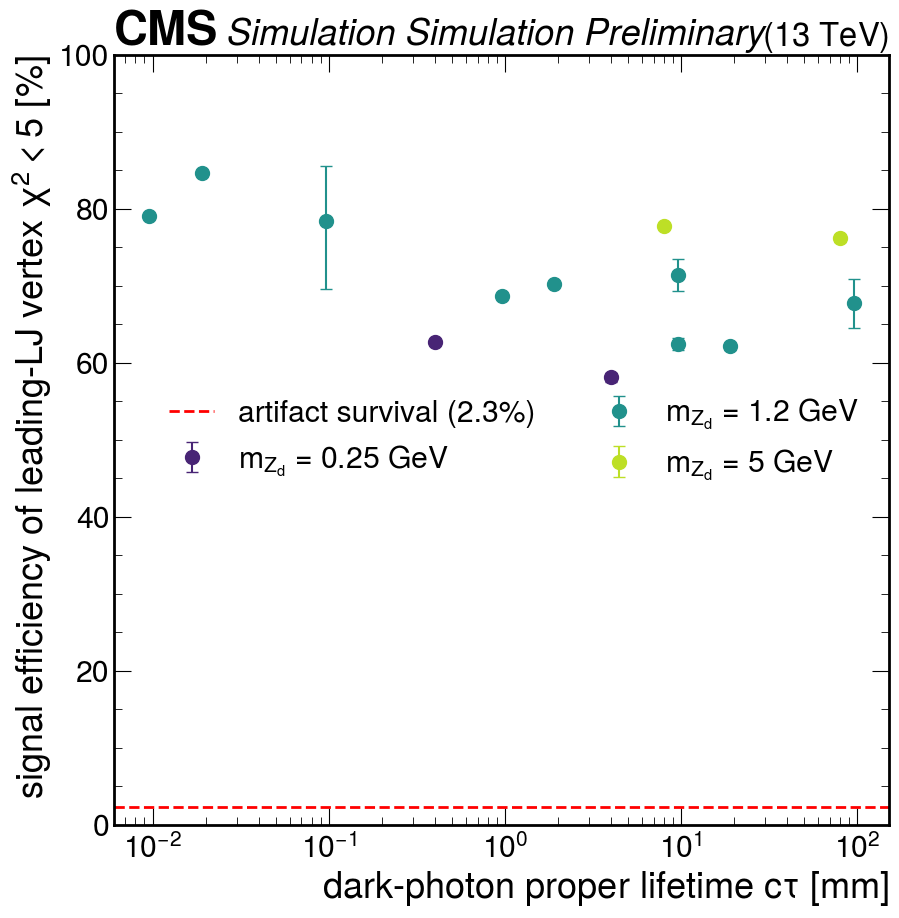

In [6]:
import re
rows = []
for f in sorted(glob.glob(CACHE_VTX + "/4Mu_*.coffea")):
    o = cu.load(f); o = o["out"] if isinstance(o, dict) and "out" in o else o
    ds = list(o.values())[0]
    hh = (ds["hists"] if "hists" in ds else ds)["abcd_vtx_4mu"][{"channel": SIG_CH["4mu"]}]
    e = edges(hh)
    s = {"vchi2sub": sum, "mudisp0": sum, "parity": sum,
         "muiso0": slice(0, eix(e["muiso0"], 0.25), sum),
         "mjj": slice(eix(e["mjj"], 150.), len(e["mjj"]) - 1, sum)}
    v = hh[s].view()["value"]
    tot = v.sum()
    if tot < 10: continue
    name = os.path.basename(f).replace(".coffea", "")
    m = re.match(r"4Mu_(\d+)GeV_(\d+p?\d*)GeV_(\d+p?\d*)mm", name)
    mbs = float(m.group(1)); mzd = float(m.group(2).replace("p", "."))
    ctau = float(m.group(3).replace("p", "."))
    k5 = v[1:eix(e["vchi2lead"], 5.)].sum()
    rows.append((name, mbs, mzd, ctau, tot, k5))
    print("%-34s N=%6.0f  eff(chi2<5) = %4.0f%%" % (name, tot, 100 * k5 / tot))

fig, axp = plt.subplots(figsize=(10, 10))
mzds = sorted({r[2] for r in rows})
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(mzds)))
for mzd, col in zip(mzds, cmap):
    pts = [(r[3], r[4], r[5]) for r in rows if r[2] == mzd]
    x = [p[0] for p in pts]
    eff = [100 * p[2] / p[1] for p in pts]
    lo_hi = [cp_interval(int(p[2]), int(p[1])) for p in pts]
    yerr = [[e - 100 * lh[0] for e, lh in zip(eff, lo_hi)],
            [100 * lh[1] - e for e, lh in zip(eff, lo_hi)]]
    axp.errorbar(x, eff, yerr=yerr, fmt="o", ms=10, color=col, capsize=4,
                 label="$m_{Z_d}$ = %g GeV" % mzd)
axp.axhline(2.25, color="red", ls="--", lw=2, label="artifact survival (2.3%)")
axp.set_xscale("log")
axp.set_xlabel("dark-photon proper lifetime $c\\tau$ [mm]")
axp.set_ylabel("signal efficiency of leading-LJ vertex $\\chi^2<5$ [%]")
axp.set_ylim(0, 100)
axp.legend(ncol=2)
hep.cms.label("Simulation Preliminary", ax=axp)
plt.show()

## 6. ABCD after vertex cleaning — and the dilution trap

If the artifact were the whole problem, removing it should restore closure.
Requiring the leading LJ to carry a good vertex (χ² ∈ (0, 5)) and re-running
every closure test:

The first line below is the trap. The **unconditioned** cleaned closure comes
out near 1.1 — the number one would naively quote, and it looks almost
acceptable. It is a **dilution artifact**: summing over the leading-LJ isolation
mixes background configurations whose correlations partially cancel. The signal
region does not sum over leading-LJ isolation — it *cuts* on it (the blind box
is defined on it) — and every signal-region-faithful variant fails:
conditioning on the leading LJ being isolated pushes closure to 1.73 ± 0.20
(sent-in, a 3.6σ non-closure) or 1.52 ± 0.19 (sent-out, 2.8σ), and the
cross-object and same-LJ planes sit at 1.6–4.1.

In [7]:
VTXC = {"vchi2lead": ("window", 0.0, 5.0)}
report("cleaned: muiso1 x mJJ | vtx, unconditioned (sent-in)",
       closure_4mu("muiso1", 0.25, cond=VTXC))
report("cleaned: muiso1 x mJJ | vtx & muiso0<0.25 (sent-in)",
       closure_4mu("muiso1", 0.25, cond=dict(VTXC, muiso0=("lt", 0.25))))
report("cleaned: muiso1 x mJJ | vtx & muiso0<0.25 (sent-out)",
       closure_4mu("muiso1", 0.25, cond=dict(VTXC, muiso0=("lt", 0.25)), sentinel="out"))
report("cleaned: mudisp1 x mJJ | vtx, unconditioned (sent-in)",
       closure_4mu("mudisp1", 2.5, cond=VTXC))
report("cleaned cross: muiso1 x mudisp0 | vtx (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp0", 2.5, cond=VTXC))
report("cleaned cross: muiso1 x mudisp0 | vtx & muiso0<0.25 (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp0", 2.5, cond=dict(VTXC, muiso0=("lt", 0.25))))
report("cleaned cross: muiso0 x mudisp1 | vtx (sent-in)",
       closure_plane("muiso0", 0.25, "mudisp1", 2.5, cond=VTXC))
report("cleaned same-LJ: muiso1 x mudisp1 | vtx (sent-in)",
       closure_plane("muiso1", 0.25, "mudisp1", 2.5, cond=VTXC))

cleaned: muiso1 x mJJ | vtx, unconditioned (sent-in)       A=   614 B=  4046 C=   462 D=  3366  R = 1.106 +- 0.073


cleaned: muiso1 x mJJ | vtx & muiso0<0.25 (sent-in)        A=   329 B=   680 C=   139 D=   498  R = 1.733 +- 0.203


cleaned: muiso1 x mJJ | vtx & muiso0<0.25 (sent-out)       A=   267 B=   680 C=   129 D=   498  R = 1.516 +- 0.185


cleaned: mudisp1 x mJJ | vtx, unconditioned (sent-in)      A=   499 B=  4161 C=   319 D=  3509  R = 1.319 +- 0.099


cleaned cross: muiso1 x mudisp0 | vtx (sent-in)            A=   178 B=   531 C=   898 D=  6881  R = 2.569 +- 0.240


cleaned cross: muiso1 x mudisp0 | vtx & muiso0<0.25 (sent-in) A=   129 B=    99 C=   339 D=  1079  R = 4.147 +- 0.611


cleaned cross: muiso0 x mudisp1 | vtx (sent-in)            A=   218 B=   600 C=  1428 D=  6242  R = 1.588 +- 0.134


cleaned same-LJ: muiso1 x mudisp1 | vtx (sent-in)          A=   213 B=   605 C=   863 D=  6807  R = 2.777 +- 0.243


**The 4mu verdict.** With the artifact removed, the remaining — physical —
background still violates the factorization assumption on every axis pairing:
the residual events carry a genuine correlation between the two LJs' isolations
and mJJ (soft QCD activity produces both LJs, so their surroundings are not
independent, and both scale with the event's hardness). This closes the
isolation-ABCD program for 4mu at full 2018 statistics: **the 4mu background
estimate requires a non-ABCD method.** The candidates — all of which exploit the
one structure ABCD ignores, the smooth mJJ spectrum against a resonant signal —
are tested in Part 3 on a dedicated fine-binned mJJ campaign:

1. **Bump-hunt**: fit a smooth shape to the vertex-cleaned isolated-corner mJJ
   spectrum; the signal is a narrow mJJ resonance.
2. **MC-assisted**: validate background-MC mJJ shapes against the vertex-cleaned
   data sidebands, then use the shape (not the normalization) under the signal.
3. **Transfer factor**: measure the isolation pass/fail ratio as a smooth
   function of mJJ where visible, and extrapolate it under the signal region.

The same three methods are evaluated in 2mu2e in parallel: if one of them
matches the deployed ABCD there, a **single unified method for both channels**
becomes possible — methodological simplicity this analysis explicitly favors.

## 7. 2mu2e cross-checks: era stability and an alternative plane

The deployed 2mu2e estimate carries two documented tensions (Part 1, Section 7).
Both are recomputed here from the merged per-era files.

**Era stability.** The sideband closure per 2018 era, and the B-region rate per
unit luminosity. Since some per-era A counts are tiny, era compatibility is
tested by comparing each era's observed A to its own B·C/D prediction with a
Poisson likelihood-ratio statistic, not with Gaussian errors on R. Three eras
agree well; 2018C is low (observed 2 where ~9 are predicted, one-sided
p ≈ 0.006 before accounting for having looked at four eras; the per-era test
also treats B·C/D as exact, so single-era tensions are somewhat overstated —
the combined value is robust to this). The B-region *rate* rises monotonically
through the year (significance against a constant per-lumi rate computed
below). The timing is consistent with the HEM15/16 calorimeter failure (two
HCAL-endcap sectors lost power partway through 2018) — an attribution we treat
as a hypothesis. Both are documented caveats of the deployed estimate, not
corrections we apply.

**Alternative plane egmiso × mJJ.** An independent prediction from a different
axis pairing. Its central value comes out 39% below the deployed plane's — a
difference of more than 3σ in the statistical uncertainties alone. The two
constructions embed different assumptions (this one folds any
isolation–mass correlation into the plane itself), so the spread is a
**plane-choice systematic that the ±14% closure precision does not cover**.
Resolving it — rather than inflating the uncertainty to swallow it — is one of
the stated goals of the Part-3 shape-based methods in 2mu2e.

In [8]:
LUMI = {"2018A": 14.03, "2018B": 7.06, "2018C": 6.90, "2018D": 31.74}  # /fb (sums to 59.7; "59.8" elsewhere is the rounded full-2018 value)

def quad2(h2, e2, egm_pass, mud_pass, lo, hi):
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),
         "mjj":    slice(eix(e2["mjj"], lo), (len(e2["mjj"]) - 1) if hi is None else eix(e2["mjj"], hi), sum),
         "parity": sum}
    s["egmiso"] = (slice(0, eix(e2["egmiso"], 0.10), sum) if egm_pass
                   else slice(eix(e2["egmiso"], 0.10), len(e2["egmiso"]) - 1, sum))
    s["mudisp"] = (slice(0, eix(e2["mudisp"], 2.5), sum) if mud_pass
                   else slice(eix(e2["mudisp"], 2.5), len(e2["mudisp"]) - 1, sum))
    return val(h2[s])

print("Per-era sideband closure (egmiso x mudisp, mJJ 50-150) and B-region rate:")
quads, brates = [], []
for era in ("2018A", "2018B", "2018C", "2018D"):
    He, ne = load_sum(CACHE_VTX, "DoubleMuon_%s*.coffea" % era, keep=["abcd_scan_2mu2e_iso_iso"])
    assert ne > 0, "no merged files for %s - check the filename pattern" % era
    h2e = He["abcd_scan_2mu2e_iso_iso"][{"channel": DATA_CH["2mu2e"]}]
    e2e = edges(h2e)
    qA = quad2(h2e, e2e, True, True, 50., 150.);  qB = quad2(h2e, e2e, False, True, 50., 150.)
    qC = quad2(h2e, e2e, True, False, 50., 150.); qD = quad2(h2e, e2e, False, False, 50., 150.)
    R, dR = closure(qA, qB, qC, qD)
    BSR = quad2(h2e, e2e, False, True, 150., None)   # B region at mJJ>=150 (open)
    print("  %s (%5.2f/fb, %d files): A=%5.0f B=%5.0f C=%5.0f D=%5.0f  R=%.2f+-%.2f | B(mJJ>=150)=%4.0f -> %5.1f ev/fb"
          % (era, LUMI[era], ne, qA, qB, qC, qD, R, dR, BSR, BSR / LUMI[era]))
    quads.append((qA, qB, qC, qD))
    brates.append((era, BSR, LUMI[era]))

# Era compatibility: per era, compare the observed A to its own B*C/D prediction
# with a Poisson likelihood-ratio statistic (Gaussian errors on R are meaningless
# at counts as small as A=2).
from scipy import stats as st
csum = 0.0
print()
for era, (qA, qB, qC, qD) in zip(("2018A", "2018B", "2018C", "2018D"), quads):
    mu = qB * qC / qD
    c = 2 * ((qA * math.log(qA / mu) if qA > 0 else 0.0) - (qA - mu))
    p1 = st.poisson.cdf(qA, mu) if qA < mu else st.poisson.sf(qA - 1, mu)
    csum += c
    print("  %s: observed A=%3.0f vs predicted %5.1f  ->  LR stat %.1f, one-sided Poisson p = %.3f"
          % (era, qA, mu, c, p1))
print("Combined Poisson LR = %.1f for 4 eras (p = %.2f); 2018C is the only era in tension."
      % (csum, st.chi2.sf(csum, 4)))

# B-region rate vs a constant per-lumi rate (Poisson likelihood ratio):
rhat = sum(b for _, b, _ in brates) / sum(l for _, _, l in brates)
lr = 0.0
for era, b, l in brates:
    mu = rhat * l
    lr += 2 * ((b * math.log(b / mu) if b > 0 else 0.0) - (b - mu))
print("\nB-region rate vs constant %.2f ev/fb: Poisson LR = %.1f / 3 dof (p = %.4f)"
      % (rhat, lr, st.chi2.sf(lr, 3)))
print("  -> quantifies the monotonic rise through 2018; see the text for the HEM15/16 hypothesis.")

# Alternative plane: egmiso x mJJ (mudisp fixed at its SR value)
H2, _ = load_sum(CACHE_VTX, "DoubleMuon_*.coffea", keep=["abcd_scan_2mu2e_iso_iso"])
h2 = H2["abcd_scan_2mu2e_iso_iso"][{"channel": DATA_CH["2mu2e"]}]
e2 = edges(h2)
def quad_alt(egm_pass, mjj_hi_side, lo=50., mid=150.):
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),
         "mudisp": slice(0, eix(e2["mudisp"], 2.5), sum),
         "parity": sum}
    s["egmiso"] = (slice(0, eix(e2["egmiso"], 0.10), sum) if egm_pass
                   else slice(eix(e2["egmiso"], 0.10), len(e2["egmiso"]) - 1, sum))
    s["mjj"] = (slice(eix(e2["mjj"], mid), len(e2["mjj"]) - 1, sum) if mjj_hi_side
                else slice(eix(e2["mjj"], lo), eix(e2["mjj"], mid), sum))
    return val(h2[s])

aB = quad_alt(False, True); aC = quad_alt(True, False); aD = quad_alt(False, False)
apred = aB * aC / aD
astat = apred * math.sqrt(1/aB + 1/aC + 1/aD)
print("\nAlternative 2mu2e plane egmiso x mJJ (A blinded):")
print("  B=%.0f C=%.0f D=%.0f  ->  A_pred = %.1f +- %.1f" % (aB, aC, aD, apred, astat))

# window closure with A=[100,150) vs control [50,100)
def quad_alt_win(egm_pass, upper):
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),
         "mudisp": slice(0, eix(e2["mudisp"], 2.5), sum),
         "parity": sum}
    s["egmiso"] = (slice(0, eix(e2["egmiso"], 0.10), sum) if egm_pass
                   else slice(eix(e2["egmiso"], 0.10), len(e2["egmiso"]) - 1, sum))
    s["mjj"] = (slice(eix(e2["mjj"], 100.), eix(e2["mjj"], 150.), sum) if upper
                else slice(eix(e2["mjj"], 50.), eix(e2["mjj"], 100.), sum))
    return val(h2[s])
wA, wB = quad_alt_win(True, True), quad_alt_win(False, True)
wC, wD = quad_alt_win(True, False), quad_alt_win(False, False)
wR, wdR = closure(wA, wB, wC, wD)
print("  window closure (A=[100,150) vs [50,100)): A=%.0f B=%.0f C=%.0f D=%.0f  R = %.3f +- %.3f"
      % (wA, wB, wC, wD, wR, wdR))
print("\nDeployed-plane prediction (Part 1): 82.9 +- 7.0; the two planes differ by")
print("  %.0f%% of the deployed value - see text." % (100 * abs(apred - 82.9) / 82.9))

Per-era sideband closure (egmiso x mudisp, mJJ 50-150) and B-region rate:


  2018A (14.03/fb, 3 files): A=   12 B=   39 C=  318 D= 1086  R=1.05+-0.35 | B(mJJ>=150)=  22 ->   1.6 ev/fb


  2018B ( 7.06/fb, 14 files): A=    5 B=   27 C=  161 D=  599  R=0.69+-0.34 | B(mJJ>=150)=  15 ->   2.1 ev/fb


  2018C ( 6.90/fb, 1 files): A=    2 B=   30 C=  161 D=  535  R=0.22+-0.16 | B(mJJ>=150)=  22 ->   3.2 ev/fb


  2018D (31.74/fb, 50 files): A=   54 B=  145 C=  783 D= 2483  R=1.18+-0.19 | B(mJJ>=150)= 107 ->   3.4 ev/fb

  2018A: observed A= 12 vs predicted  11.4  ->  LR stat 0.0, one-sided Poisson p = 0.471
  2018B: observed A=  5 vs predicted   7.3  ->  LR stat 0.8, one-sided Poisson p = 0.269
  2018C: observed A=  2 vs predicted   9.0  ->  LR stat 8.0, one-sided Poisson p = 0.006
  2018D: observed A= 54 vs predicted  45.7  ->  LR stat 1.4, one-sided Poisson p = 0.126
Combined Poisson LR = 10.3 for 4 eras (p = 0.04); 2018C is the only era in tension.

B-region rate vs constant 2.78 ev/fb: Poisson LR = 14.1 / 3 dof (p = 0.0027)
  -> quantifies the monotonic rise through 2018; see the text for the HEM15/16 hypothesis.



Alternative 2mu2e plane egmiso x mJJ (A blinded):
  B=166 C=73 D=241  ->  A_pred = 50.3 +- 7.8


  window closure (A=[100,150) vs [50,100)): A=50 B=168 C=23 D=73  R = 0.945 +- 0.272

Deployed-plane prediction (Part 1): 82.9 +- 7.0; the two planes differ by
  39% of the deployed value - see text.


## 8. Summary of every closure measured at full 2018 statistics

| Channel | Sample | Plane | Conditions | R (closure) | Verdict |
|---|---|---|---|---|---|
| 2mu2e | all | egmiso × mudisp | SR cuts, sideband | 1.001 ± 0.137 (Part 1) | **deployed** |
| 2mu2e | all | egmiso × mJJ | SR cuts | 0.95 ± 0.27 (Sec. 7) | cross-check; 39% prediction spread documented |
| 4mu | raw | muiso1 × mJJ | uncond / cond | 2.9 / 4.0 (Sec. 2) | fails — artifact-dominated |
| 4mu | raw | cross & same-LJ iso × disp | uncond / cond | 15–35 (Sec. 3) | fails — artifact-dominated |
| 4mu | vertex-cleaned | muiso1 × mJJ | unconditioned | 1.11 ± 0.07 (Sec. 6) | *misleading* — dilution; SR cannot use it |
| 4mu | vertex-cleaned | muiso1 × mJJ | muiso0 < 0.25, sent-in / sent-out | 1.73 / 1.52 | fails |
| 4mu | vertex-cleaned | muiso1 × mudisp0 | uncond / + muiso0 < 0.25 | 2.57 / 4.15 | fails |
| 4mu | vertex-cleaned | muiso0 × mudisp1 | uncond | 1.59 | fails |
| 4mu | vertex-cleaned | muiso1 × mudisp1 (same LJ) | uncond | 2.78 | fails |

(Values from the executed cells above, which are the authoritative live
recomputation; they reproduce the campaign log exactly.)

**Conclusions.**

1. 2mu2e has a deployed ABCD estimate whose own closure is validated at the
   ±14% level. Its open caveats — the mJJ extrapolation, the 2018C era tension
   (combined era p ≈ 0.04), and a 39% plane-choice spread that the ±14% does
   *not* cover — are documented above and are inputs to Part 3, not resolved
   issues.
2. 4mu has **no** viable isolation-based ABCD: the instrumental artifact is
   understood and removable, but the *physical* residual background itself
   violates factorization.
3. Every future 4mu method inherits two assets from this campaign: the
   **vertex-cleaning discriminant** (~98% artifact rejection; 58–85% signal
   efficiency at χ² < 5 from simulation; genuine-vs-fake separation validated
   in data on prompt Z → μμ pairs) and the **fine-binned mJJ campaign**
   designed for the three shape-based methods of Part 3.